In [ ]:
from pathlib import Path
import yaml
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Get the memory network run directory
for base in [Path.cwd(), *Path.cwd().parents]:
    run = base / "runs" / "memory_network_id2604161148"
    if run.is_dir():
        break
else:
    raise FileNotFoundError("runs/memory_network_id2604161148")

# Load the hyperparameters
with open(run / "hparams.yaml") as f:
    hp = yaml.safe_load(f)

# Extract the hyperparameters
ranks = list(hp["ranks"])
connectome = np.asarray(hp["connectome"], int)
lag = int(hp["lag"])
memory = int(hp["memory"])

# Extract the data 
with h5py.File(run / "data.h5", "r") as h:
    g = h["0"]
    truth = g["truth-inp"][:]
    mesgs = g["message-mesgs"][:]
    latents = g["message-latents"][:]
    h0 = g["area-A0"][:]
    h1 = g["area-A1"][:]
    h2 = g["area-A2"][:]

# print("truth.shape:", truth.shape)
# print("mesgs.shape:", mesgs.shape)
# print("latents.shape:", latents.shape)
# print("h0.shape:", h0.shape)
# print("h1.shape:", h1.shape)
# print("h2.shape:", h2.shape)

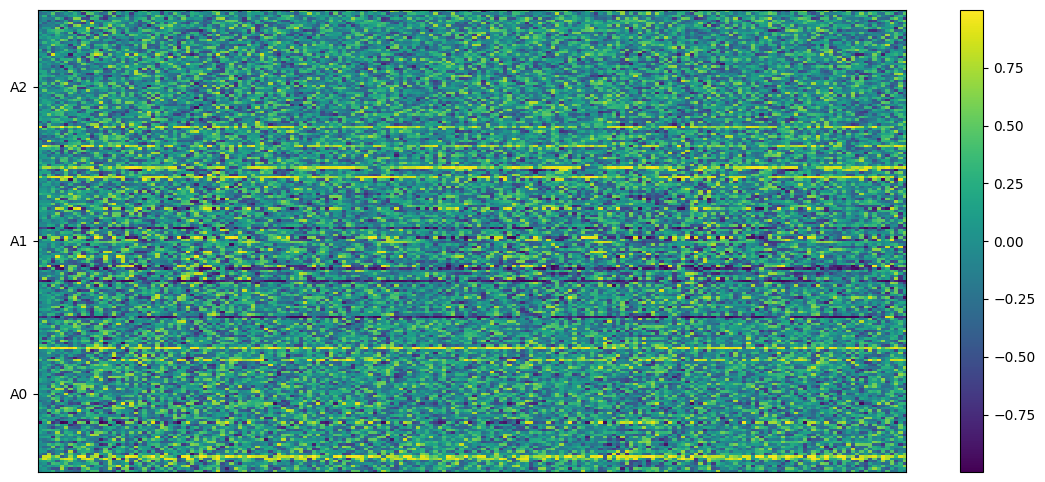

In [151]:
# Visualize hidden activity

trial_idx = 0
h_trial = np.concatenate([h0[trial_idx], h1[trial_idx], h2[trial_idx]], axis=-1)

plt.figure(figsize=(14, 6))
plt.imshow(h_trial.T, aspect="auto", origin="lower", interpolation="nearest")
plt.colorbar()
plt.xticks([])

area_size = 64
centers = [area_size/2 - 0, 3 * area_size/2 - 0.5, 5 * area_size/2 - 0.5]
plt.yticks(centers, ["A0", "A1", "A2"])

plt.show()

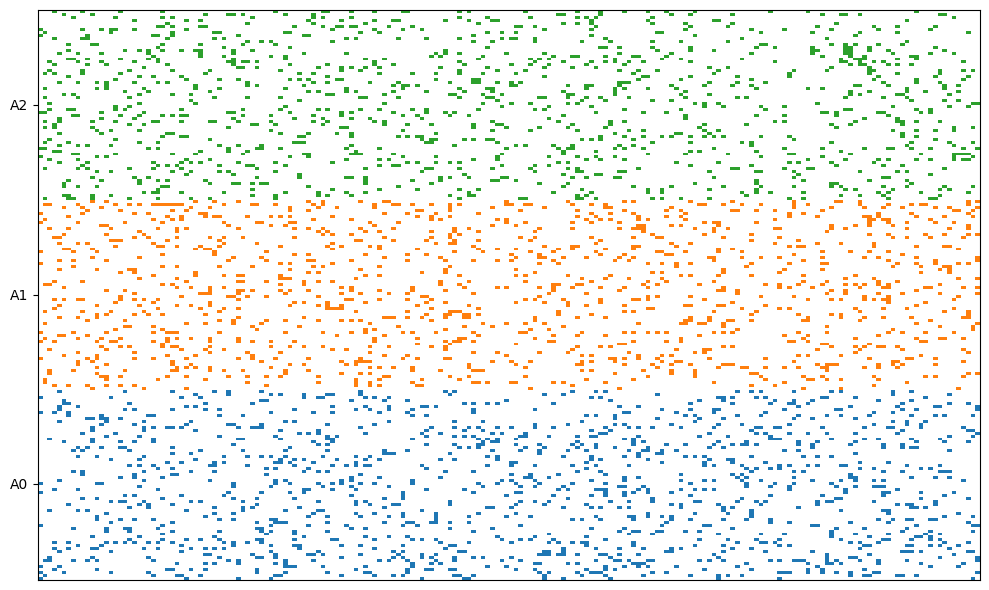

In [149]:
# Visualize hidden activity as a raster plot of spikes

trial_idx = 0
h_trial = np.concatenate([h0[trial_idx], h1[trial_idx], h2[trial_idx]], axis=-1)
dt = 0.1

rates = np.exp(h_trial) # hidden activity -> positive rates
lam = rates * dt # expected counts/bin
counts = np.random.poisson(lam) # integer counts
spikes = (counts > 0).astype(np.int32) # binary spikes

T, N = spikes.shape

n_blocks = 3
colors = plt.cm.tab10(range(n_blocks))[:, :3]

# Build RGB image
rgb = np.ones((T, N, 3))
block_ids = np.arange(N) // 64

# Map neurons to colors
neuron_colors = colors[block_ids]

# Apply spikes mask
rgb = np.where(spikes[..., None], neuron_colors[None, :, :], rgb)

plt.figure(figsize=(10, 6))
plt.imshow(rgb.transpose(1, 0, 2), aspect="auto", origin="lower", interpolation="nearest")
plt.xticks([])
# plt.xlabel("Time step")
# plt.ylabel("Neuron")

area_size = 64
centers = [area_size/2 - 0, 3 * area_size/2 - 0.5, 5 * area_size/2 - 0.5]
plt.yticks(centers, ["A0", "A1", "A2"])

plt.tight_layout()
plt.show()